In [6]:
import pandas as pd

df = pd.read_excel(r"D:\Downloads\EF (1).xlsx", usecols="A:C")
print(df.columns)

Index(['PARAMETER', 'Return', 'Risk'], dtype='object')


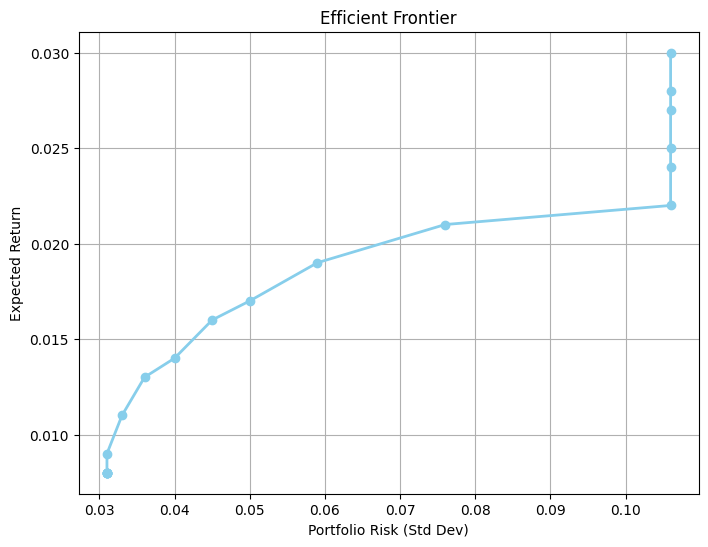

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(df["Risk"], df["Return"], marker='o', color='skyblue', linewidth=2)
plt.title("Efficient Frontier")
plt.xlabel("Portfolio Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.grid(True)
plt.show()


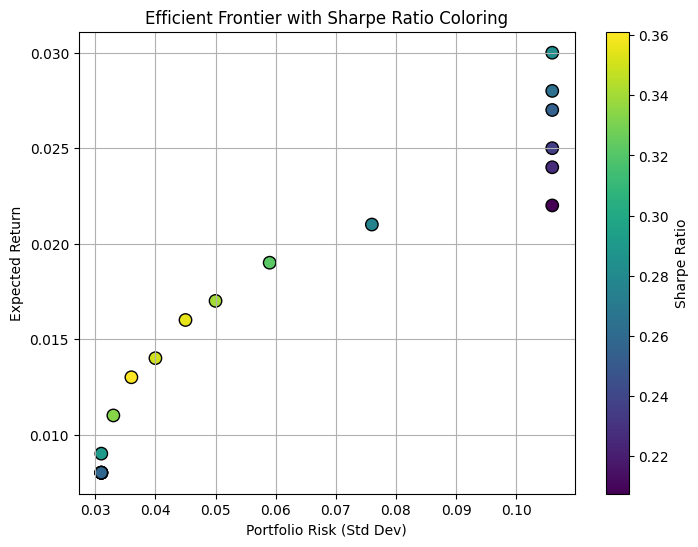

In [9]:
df["Sharpe"] = df["Return"] / df["Risk"]

# Plot with color scale
plt.figure(figsize=(8,6))
scatter = plt.scatter(df["Risk"], df["Return"],
                      c=df["Sharpe"], cmap="viridis", s=80, edgecolors="black")

plt.title("Efficient Frontier with Sharpe Ratio Coloring")
plt.xlabel("Portfolio Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.colorbar(scatter, label="Sharpe Ratio")
plt.grid(True)
plt.show()

In [10]:
# Compute Sharpe ratio (risk-free rate = 0 for now)
df["Sharpe"] = df["Return"] / df["Risk"]

# Identify the max Sharpe portfolio
opt = df.loc[df["Sharpe"].idxmax()]
opt_risk = opt["Risk"]
opt_ret  = opt["Return"]
opt_sharpe = opt["Sharpe"]

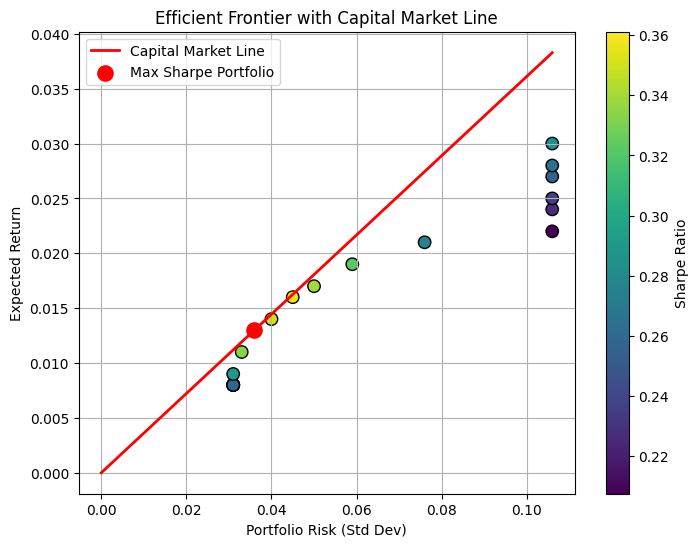

In [11]:
plt.figure(figsize=(8,6))

# Efficient frontier
plt.scatter(df["Risk"], df["Return"], c=df["Sharpe"], cmap="viridis", s=80, edgecolors="black")
plt.colorbar(label="Sharpe Ratio")

# Capital Market Line (risk-free rate = 0)
rf = 0
max_risk = df["Risk"].max()
cml_x = [0, max_risk]
cml_y = [rf, rf + opt_sharpe * max_risk]

plt.plot(cml_x, cml_y, color="red", linewidth=2, label="Capital Market Line")

# Highlight max Sharpe portfolio
plt.scatter(opt_risk, opt_ret, color="red", s=120, label="Max Sharpe Portfolio")

plt.title("Efficient Frontier with Capital Market Line")
plt.xlabel("Portfolio Risk (Std Dev)")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True)
plt.show()